# Backdoor Robustness in CNN-Based Image Classifiers

This notebook is the main interface for the Deep Learning course project. It studies CIFAR-10 classifiers under pixel and semantic backdoor attacks, compares Simple CNN and ResNet18, and evaluates whether parameter-update analysis with rollback reduces attack success rate while preserving clean accuracy.

## 1. Setup

Choose a preset, configure whether to run new experiments or load cached JSON files, and import the project modules.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch

import config as cfg
from main import build_experiment_request, run_experiment, set_seed
from models import get_model

NOTEBOOK_PRESET = "medium"
RUN_EXPERIMENTS = True
SAVE_JSON = True
RESULTS_DIR = Path("results")
ASSET_DIR = Path("assets/readme")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

set_seed(cfg.SEED)
DEVICE = cfg.resolve_device(None)
print(f"Device: {DEVICE}")

Device: cuda


## 2. Dataset and Backdoor Setup

The project uses CIFAR-10 with pixel and semantic triggers adapted from the SafeSplit reproduction. Poisoning is applied directly to the centralized training dataset when an attack is enabled.

In [2]:
from data import PixelTriggerAttack, SemanticTriggerAttack, load_datasets
from data.dataset import CIFAR10_MEAN, CIFAR10_STD

train_dataset, test_dataset = load_datasets(cfg.DATA_DIR)
print(f"Train samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

pixel_attack = PixelTriggerAttack(cfg.TRIGGER_SIZE, cfg.TRIGGER_POS, cfg.PIXEL_TARGET_LABEL)
semantic_attack = SemanticTriggerAttack(cfg.SEMANTIC_SOURCE_LABEL, cfg.SEMANTIC_TARGET_LABEL)
print("Pixel target label:", cfg.PIXEL_TARGET_LABEL)
print("Semantic source -> target:", cfg.SEMANTIC_SOURCE_LABEL, "->", cfg.SEMANTIC_TARGET_LABEL)

Train samples: 50,000
Test samples: 10,000
Pixel target label: 0
Semantic source -> target: 1 -> 2


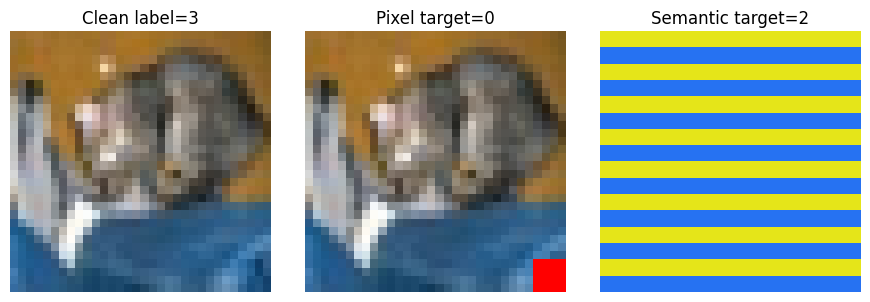

In [3]:
def denormalize(image):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1)

clean_image, clean_label = test_dataset[0]
pixel_image, pixel_label = pixel_attack.poison_sample(clean_image, clean_label)

semantic_example = next(i for i, target in enumerate(test_dataset.targets) if target == cfg.SEMANTIC_SOURCE_LABEL)
semantic_clean, semantic_label = test_dataset[semantic_example]
semantic_image, semantic_target = semantic_attack.poison_sample(semantic_clean, semantic_label)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
examples = [
    (clean_image, f"Clean label={clean_label}"),
    (pixel_image, f"Pixel target={pixel_label}"),
    (semantic_image, f"Semantic target={semantic_target}"),
]
for ax, (image, title) in zip(axes, examples):
    ax.imshow(denormalize(image).permute(1, 2, 0))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(ASSET_DIR / "trigger-examples.png", dpi=160)
plt.show()

## 3. Models

Both architectures expose the same interface: a single `forward(x)` returning logits. Internally they keep `head`, `backbone`, and `tail` blocks so the update defense can analyze a stable submodule.

In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_rows = []
for arch in ["simple_cnn", "resnet18"]:
    model = get_model(arch, cfg.NUM_CLASSES)
    x = torch.randn(2, 3, 32, 32)
    with torch.no_grad():
        logits = model(x)
    model_rows.append({"model": arch, "parameters": count_parameters(model), "logit_shape": tuple(logits.shape)})

model_table = pd.DataFrame(model_rows)
model_table

,model,parameters,logit_shape
0,simple_cnn,111498,"(2, 10)"
1,resnet18,11173962,"(2, 10)"


## 4. Experiment Runner

Set `RUN_EXPERIMENTS = True` in the setup cell to execute the matrix. When it is `False`, the notebook loads existing JSON results from `results/` if available.

The matrix includes poisoning from the first epoch and delayed poisoning for defended attack runs. Delayed poisoning creates clean early checkpoints, which makes rollback a more meaningful defense test.

In [5]:
EXPERIMENTS = []
for arch in ["simple_cnn", "resnet18"]:
    EXPERIMENTS.append({"arch": arch, "backdoor": "none", "defense": "none", "poison_start_epoch": 1})
    EXPERIMENTS.append({"arch": arch, "backdoor": "none", "defense": "update_defense", "poison_start_epoch": 1})
    for attack in ["pixel", "semantic"]:
        EXPERIMENTS.append({"arch": arch, "backdoor": attack, "defense": "none", "poison_start_epoch": 1})
        EXPERIMENTS.append({"arch": arch, "backdoor": attack, "defense": "update_defense", "poison_start_epoch": 1})
        EXPERIMENTS.append({"arch": arch, "backdoor": attack, "defense": "update_defense", "poison_start_epoch": 3})


def run_matrix():
    outputs = []
    for overrides in EXPERIMENTS:
        request = build_experiment_request(
            preset=NOTEBOOK_PRESET,
            write_json=SAVE_JSON,
            device=DEVICE,
            **overrides,
        )
        print("Running", overrides)
        outputs.append(run_experiment(request))
    return outputs


def load_cached_results(results_dir=RESULTS_DIR):
    preset_config = cfg.resolve_preset(NOTEBOOK_PRESET)
    expected_epochs = int(preset_config["num_rounds"])
    expected_cases = {
        (case["arch"], case["backdoor"], case["defense"], case["poison_start_epoch"])
        for case in EXPERIMENTS
    }

    outputs = []
    for path in sorted(results_dir.glob("*.json")):
        with path.open() as f:
            payload = json.load(f)
        config = payload.get("config", {})
        poison_start = config.get("poison_start_epoch")
        if poison_start is None:
            poison_start = 1
        case = (config.get("arch"), config.get("backdoor"), config.get("defense"), int(poison_start))
        if config.get("preset") != NOTEBOOK_PRESET:
            continue
        if int(config.get("num_rounds", -1)) != expected_epochs:
            continue
        if case not in expected_cases:
            continue
        payload["results_path"] = str(path)
        outputs.append(payload)
    return outputs

results = run_matrix() if RUN_EXPERIMENTS else load_cached_results()
print(f"Loaded {len(results)} result files")

Running {'arch': 'simple_cnn', 'backdoor': 'none', 'defense': 'none', 'poison_start_epoch': 1}
Running {'arch': 'simple_cnn', 'backdoor': 'none', 'defense': 'update_defense', 'poison_start_epoch': 1}
Running {'arch': 'simple_cnn', 'backdoor': 'pixel', 'defense': 'none', 'poison_start_epoch': 1}
Running {'arch': 'simple_cnn', 'backdoor': 'pixel', 'defense': 'update_defense', 'poison_start_epoch': 1}
Running {'arch': 'simple_cnn', 'backdoor': 'pixel', 'defense': 'update_defense', 'poison_start_epoch': 3}
Running {'arch': 'simple_cnn', 'backdoor': 'semantic', 'defense': 'none', 'poison_start_epoch': 1}
Running {'arch': 'simple_cnn', 'backdoor': 'semantic', 'defense': 'update_defense', 'poison_start_epoch': 1}
Running {'arch': 'simple_cnn', 'backdoor': 'semantic', 'defense': 'update_defense', 'poison_start_epoch': 3}
Running {'arch': 'resnet18', 'backdoor': 'none', 'defense': 'none', 'poison_start_epoch': 1}
Running {'arch': 'resnet18', 'backdoor': 'none', 'defense': 'update_defense', 'poi

## 5. Results Tables

The main table is organized by model, attack, and defense. The key metrics are clean accuracy and attack success rate.

In [6]:
def poison_timing_label(config):
    if config.get("backdoor") == "none":
        return "clean"
    poison_start = config.get("poison_start_epoch")
    if poison_start in (None, 1):
        return "from_start"
    return f"delayed_epoch_{poison_start}"


def summarize_result(result):
    config = result["config"]
    history = result.get("history", [])
    return {
        "model": config.get("arch"),
        "attack": config.get("backdoor"),
        "defense": config.get("defense"),
        "poison_timing": poison_timing_label(config),
        "clean_accuracy": result.get("final_clean_accuracy", result.get("final_MA")),
        "attack_success_rate": result.get("final_attack_success_rate", result.get("final_BA")),
        "epochs": len(history),
        "rollback_count": sum(1 for row in history if row.get("rollback")),
        "results_path": result.get("results_path"),
    }

summary_df = pd.DataFrame([summarize_result(result) for result in results])
if summary_df.empty:
    print("No cached results found. Set RUN_EXPERIMENTS = True and rerun the experiment cell.")
else:
    display(summary_df.sort_values(["model", "attack", "defense", "poison_timing"]))
    summary_df.to_csv(ASSET_DIR / "main-comparison.csv", index=False)

,model,attack,defense,poison_timing,clean_accuracy,attack_success_rate,epochs,rollback_count,results_path
8,resnet18,none,none,clean,34.01,0.0,4,0,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
9,resnet18,none,update_defense,clean,33.57,0.0,4,0,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
10,resnet18,pixel,none,from_start,24.32,100.0,4,0,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
12,resnet18,pixel,update_defense,delayed_epoch_3,10.07,99.9,4,1,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
11,resnet18,pixel,update_defense,from_start,21.34,100.0,4,1,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
13,resnet18,semantic,none,from_start,30.28,100.0,4,0,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
15,resnet18,semantic,update_defense,delayed_epoch_3,27.98,100.0,4,1,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
14,resnet18,semantic,update_defense,from_start,30.64,100.0,4,0,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
0,simple_cnn,none,none,clean,27.03,0.0,4,0,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...
1,simple_cnn,none,update_defense,clean,23.98,0.0,4,1,C:\Users\mathe\Semester2\_DL\DL_Backdoor_Attac...


## 6. Training Dynamics and Robustness Plots

These plots are report-ready: clean accuracy over epochs, attack success rate over epochs, final clean accuracy, final attack success rate, and rollback counts.

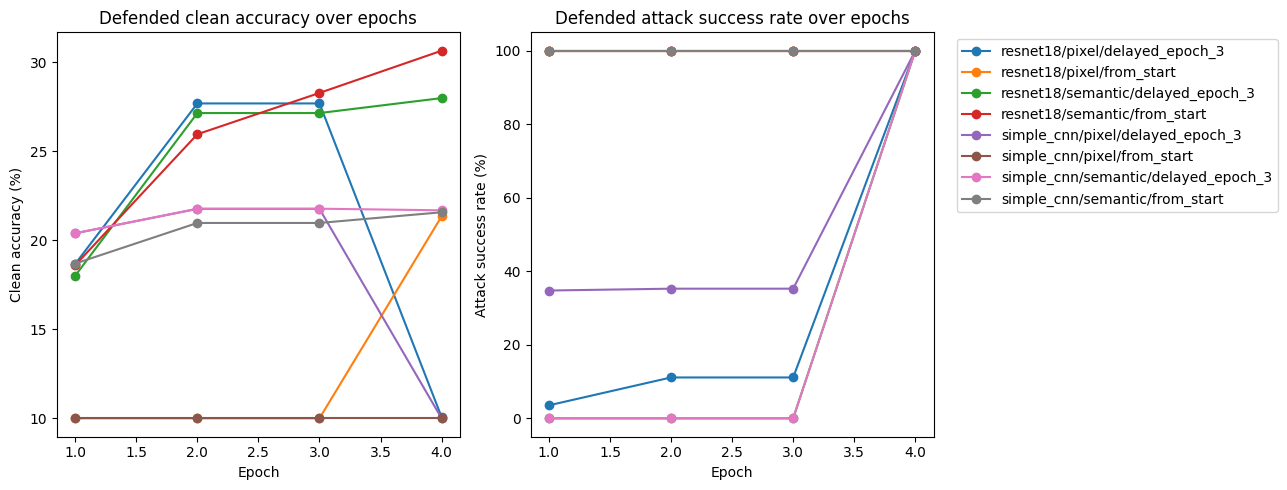

In [7]:
def history_frame(results):
    rows = []
    for result in results:
        config = result["config"]
        timing = poison_timing_label(config)
        for point in result.get("history", []):
            rows.append({
                "model": config.get("arch"),
                "attack": config.get("backdoor"),
                "defense": config.get("defense"),
                "poison_timing": timing,
                "epoch": point.get("epoch"),
                "poison_active": point.get("poison_active", False),
                "clean_accuracy": point.get("clean_accuracy", point.get("clean_ma")),
                "attack_success_rate": point.get("attack_success_rate", point.get("backdoor_ba")),
                "rollback": point.get("rollback", False),
            })
    return pd.DataFrame(rows)

history_df = history_frame(results)

if not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
    plot_history = history_df[
        (history_df["attack"] != "none")
        & (history_df["defense"] == "update_defense")
    ]
    for (model, attack, timing), group in plot_history.groupby(["model", "attack", "poison_timing"]):
        label = f"{model}/{attack}/{timing}"
        axes[0].plot(group["epoch"], group["clean_accuracy"], marker="o", label=label)
        axes[1].plot(group["epoch"], group["attack_success_rate"], marker="o", label=label)
    axes[0].set_title("Defended clean accuracy over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Clean accuracy (%)")
    axes[1].set_title("Defended attack success rate over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Attack success rate (%)")
    axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(ASSET_DIR / "training-curves.png", dpi=180, bbox_inches="tight")
    plt.show()

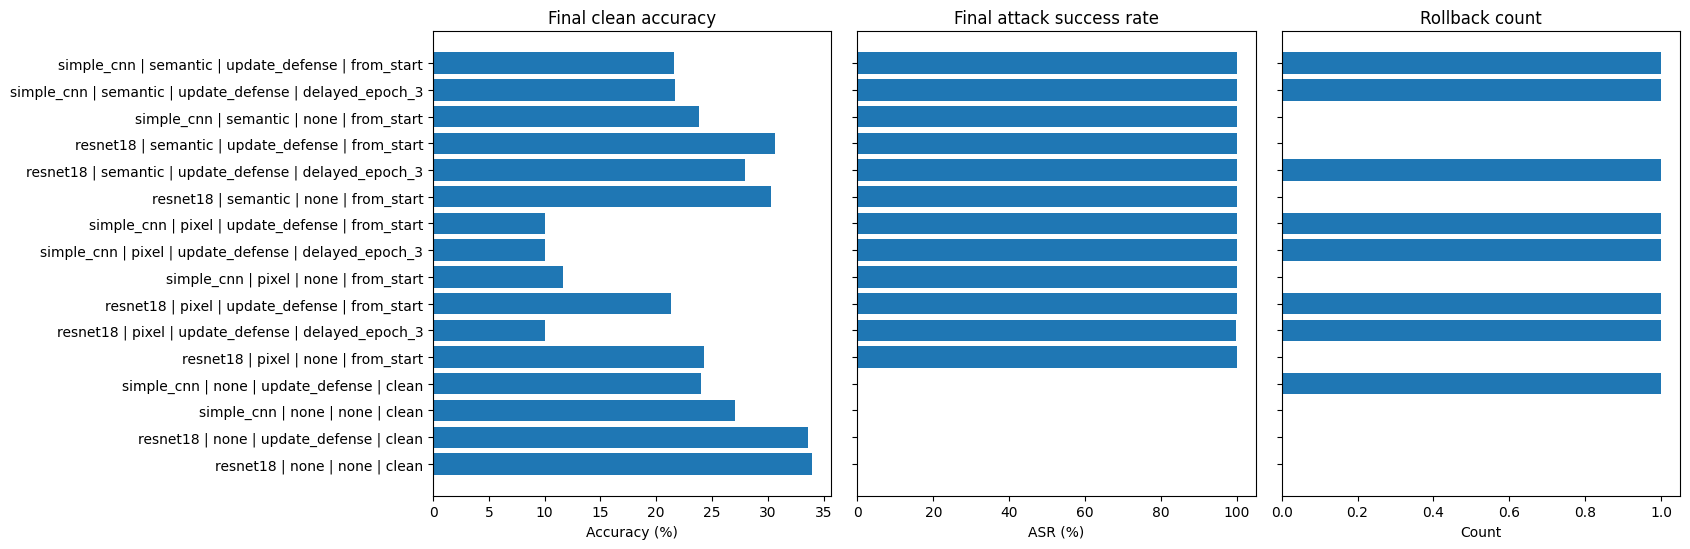

In [8]:
if not summary_df.empty:
    plot_df = summary_df.sort_values(["attack", "model", "defense", "poison_timing"]).copy()
    plot_df["label"] = (
        plot_df["model"]
        + " | " + plot_df["attack"]
        + " | " + plot_df["defense"]
        + " | " + plot_df["poison_timing"]
    )

    fig, axes = plt.subplots(1, 3, figsize=(17, max(5, 0.35 * len(plot_df))), sharey=True)
    y_pos = range(len(plot_df))

    axes[0].barh(y_pos, plot_df["clean_accuracy"])
    axes[0].set_title("Final clean accuracy")
    axes[0].set_xlabel("Accuracy (%)")
    axes[0].set_yticks(list(y_pos))
    axes[0].set_yticklabels(plot_df["label"])

    axes[1].barh(y_pos, plot_df["attack_success_rate"])
    axes[1].set_title("Final attack success rate")
    axes[1].set_xlabel("ASR (%)")

    axes[2].barh(y_pos, plot_df["rollback_count"])
    axes[2].set_title("Rollback count")
    axes[2].set_xlabel("Count")

    plt.tight_layout()
    plt.savefig(ASSET_DIR / "final-comparison.png", dpi=180, bbox_inches="tight")
    plt.show()

## 7. Analysis Prompts for the Report

Use the generated table and plots to answer:

- Which architecture keeps higher clean accuracy under the same attack and defense?
- How quickly does attack success rate increase when poisoning starts at epoch 1?
- Does delayed poisoning change the usefulness of update-based rollback?
- Does rollback need a clean checkpoint before the attack to reduce attack success rate?
- What clean-accuracy tradeoff appears when rollback selects an older checkpoint?

The exported files in `assets/readme/` can be reused directly in the README and final report.